In [3]:
# necessary initialization
%load_ext autoreload
%autoreload 2

from particle_helper import *
import matplotlib.pyplot as plt
import pygame

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
pygame 2.6.1 (SDL 2.28.4, Python 3.12.9)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [4]:
# Parameters for the ball 1
initial_positions1 = np.array([[0, 50]])
launch_speeds1 = [20]
launch_angles1 = [45]
num_drop_out_interval1= 4
init_vx1 = np.cos(np.radians(launch_angles1[0]))
init_vy1 = np.sin(np.radians(launch_angles1[0]))
init_state1 = np.array([initial_positions1[0][0], initial_positions1[0][1], launch_speeds1[0] * init_vx1, launch_speeds1[0] * init_vy1])


# Parameters for the ball 2
initial_positions2 = np.array([[0, 0]])
launch_speeds2 = [30]
launch_angles2 = [60]
num_drop_out_interval2 = 3
init_vx2 = np.cos(np.radians(launch_angles2[0]))
init_vy2 = np.sin(np.radians(launch_angles2[0]))
init_state2 = np.array([initial_positions2[0][0], initial_positions2[0][1], launch_speeds2[0] * init_vx2, launch_speeds2[0] * init_vy2])

observation_noise_std = 0.3
time_step = 0.01
total_time = 10

# Parameters for the Particle Filter
num_particles = 10000
process_noise_std = 0.01

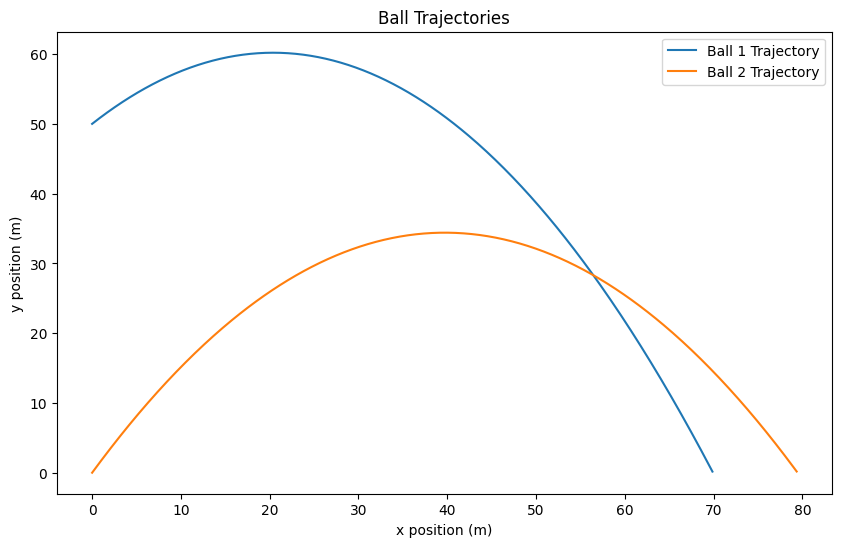

In [5]:
# Simulate trajectories for both balls
positions1= simulate_ball_trajectory(initial_positions1, 
                                    launch_speeds1, 
                                    launch_angles1, 
                                    time_step, 
                                    total_time)

positions2= simulate_ball_trajectory(initial_positions2, 
                                    launch_speeds2, 
                                    launch_angles2, 
                                    time_step, 
                                    total_time)

# Plot the positions of both balls
plt.figure(figsize=(10, 6))
plt.plot(positions1[:,0], positions1[:,1], label='Ball 1 Trajectory')
plt.plot(positions2[:,0], positions2[:,1], label='Ball 2 Trajectory')
plt.xlabel('x position (m)')
plt.ylabel('y position (m)')
plt.legend()
plt.title('Ball Trajectories')
plt.show()

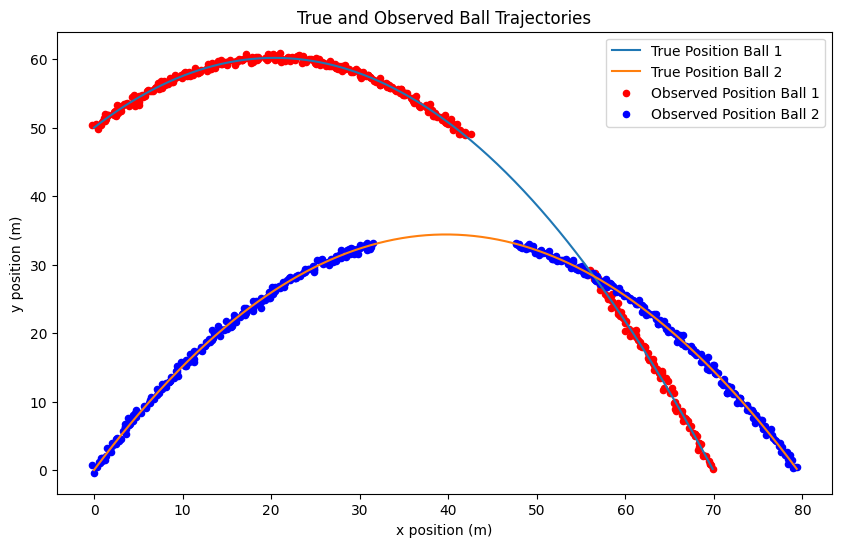

In [6]:
noisy_positions1 = simulate_observations(positions1, observation_noise_std, num_drop_out_interval1)
noisy_positions2 = simulate_observations(positions2, observation_noise_std, num_drop_out_interval2)

# Plot the true and noisy positions of both balls
plt.figure(figsize=(10, 6))
plt.plot(positions1[:,0], positions1[:,1], label='True Position Ball 1')
plt.plot(positions2[:,0], positions2[:,1], label='True Position Ball 2')
plt.scatter(noisy_positions1[:,0], noisy_positions1[:,1], color='red', label='Observed Position Ball 1', s=20)
plt.scatter(noisy_positions2[:,0], noisy_positions2[:,1], color='blue', label='Observed Position Ball 2', s=20)
plt.xlabel('x position (m)')
plt.ylabel('y position (m)')
plt.legend()
plt.title('True and Observed Ball Trajectories')
plt.show()


In [7]:
pf1 = ParticleFilter(num_particles, process_noise_std, 3, init_state1)
estimated_positions1 = []
all_particles1 = []

for t in range(len(noisy_positions1)):        
    pf1.resample()
    pf1.predict(time_step)
    pf1.update(noisy_positions1[t])
    est_pos1 = pf1.estimate()
    estimated_positions1.append(est_pos1)
    all_particles1.append(pf1.particles)
    
all_particles1 = np.array(all_particles1)    
estimated_positions1 = np.array(estimated_positions1)

In [8]:
pf2 = ParticleFilter(num_particles, process_noise_std, 0.3, init_state2)
estimated_positions2 = []
all_particles2 = []

for t in range(len(noisy_positions2)):        
    pf2.resample()
    pf2.predict(time_step)
    pf2.update(noisy_positions2[t])
    est_pos2 = pf2.estimate()
    estimated_positions2.append(est_pos2)
    all_particles2.append(pf2.particles)
    
all_particles2 = np.array(all_particles2)
estimated_positions2 = np.array(estimated_positions2)

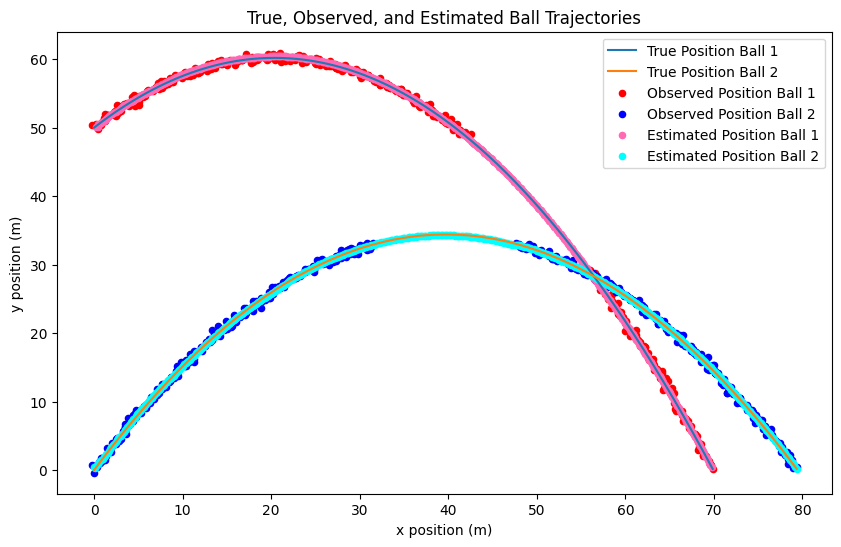

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(positions1[:,0], positions1[:,1], label='True Position Ball 1')
plt.plot(positions2[:,0], positions2[:,1], label='True Position Ball 2')
plt.scatter(noisy_positions1[:,0], noisy_positions1[:,1], color='red', label='Observed Position Ball 1', s=20)
plt.scatter(noisy_positions2[:,0], noisy_positions2[:,1], color='blue', label='Observed Position Ball 2', s=20)
plt.scatter(estimated_positions1[:,0], estimated_positions1[:,1], color='hotpink', label='Estimated Position Ball 1', s=20)
plt.scatter(estimated_positions2[:,0], estimated_positions2[:,1], color='cyan', label='Estimated Position Ball 2', s=20)
plt.xlabel('x position (m)')
plt.ylabel('y position (m)')
plt.legend()
plt.title('True, Observed, and Estimated Ball Trajectories')
plt.show()


In [11]:

pygame.init()
screen = pygame.display.set_mode((1000, 750))
pygame.display.set_caption('Particle Filter Animation')
clock = pygame.time.Clock()

# Initialize font
font = pygame.font.SysFont(None, 24)


# Function to draw the scene
def draw_scene(frame):
    screen.fill((255, 255, 255))
    
    # Draw true positions
    for pos in positions1[:frame+1]:
        pygame.draw.circle(screen, (0, 255, 0), (int(pos[0]*10), 750 - int(pos[1]*10)), 3)
    for pos in positions2[:frame+1]:
        pygame.draw.circle(screen, (0, 0, 255), (int(pos[0]*10), 750 - int(pos[1]*10)), 3)
    
    # Draw observed positions
    for pos in noisy_positions1[:frame+1]:
        if not np.isnan(pos).any():
            pygame.draw.circle(screen, (255, 0, 0), (int(pos[0]*10), 750 - int(pos[1]*10)), 3)
    for pos in noisy_positions2[:frame+1]:
        if not np.isnan(pos).any():
            pygame.draw.circle(screen, (255, 0, 255), (int(pos[0]*10), 750 - int(pos[1]*10)), 3)
    
    # Draw estimated positions
    for pos in estimated_positions1[:frame+1]:
        pygame.draw.circle(screen, (255, 105, 180), (int(pos[0]*10), 750 - int(pos[1]*10)), 3)
    for pos in estimated_positions2[:frame+1]:
        pygame.draw.circle(screen, (0, 255, 255), (int(pos[0]*10), 750 - int(pos[1]*10)), 3)
    
    # Draw particles frame by frame
    if frame < len(all_particles1):
        for particle in all_particles1[frame]:
            pygame.draw.circle(screen, (128, 128, 128), (int(particle[0]*10), 750 - int(particle[1]*10)), 3)
    
    if frame < len(all_particles2):
        for particle in all_particles2[frame]:
            pygame.draw.circle(screen, (128, 128, 128), (int(particle[0]*10), 750 - int(particle[1]*10)), 3)

    # Draw labels
    labels = [
        ("True Position Ball 1", (0, 255, 0)),
        ("True Position Ball 2", (0, 0, 255)),
        ("Observed Position Ball 1", (255, 0, 0)),
        ("Observed Position Ball 2", (255, 0, 255)),
        ("Estimated Position Ball 1", (255, 105, 180)),
        ("Estimated Position Ball 2", (0, 255, 255)),
        ("Particles Ball 1", (128, 128, 128)),
        ("Particles Ball 2", (128, 128, 128))
    ]
    
    for i, (text, color) in enumerate(labels):
        label = font.render(text, True, color)
        screen.blit(label, (750, 20 + i * 20))
    
    pygame.display.flip()

# Main animation loop
running = True
frame = 0
max_frames = max(len(positions1), len(positions2))  # Use the maximum length of positions1 and positions2

while running:
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False

    if frame < max_frames:
        draw_scene(frame)
        frame += 1
    else:
        running = False

    clock.tick(60)  # Run at 60 frames per second

pygame.quit()